In [1]:
import os
import sys
import platform

print("os.name:", os.name)
print("platform.system():", platform.system())
print("sys.executable:", sys.executable)
print("cwd:", os.getcwd())

os.name: posix
platform.system(): Linux
sys.executable: /usr/bin/python3
cwd: /content


In [2]:
# =========================
# CELL 1 — IMPORTS + CONFIG
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# PATH CONFIG
# =========================
PREPROCESSED_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed"
PROJECT_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research"

DATASET_NAME = "APTOS"
EXPERIMENT_NAME = "exp1_baseline"
MODEL_NAME = "mobilenet"

BASE_RESULT_DIR = os.path.join(PROJECT_DIR, "results", DATASET_NAME, EXPERIMENT_NAME, MODEL_NAME)
MODELS_DIR = os.path.join(BASE_RESULT_DIR, "models")
LOGS_DIR = os.path.join(BASE_RESULT_DIR, "logs")
FIGURES_DIR = os.path.join(BASE_RESULT_DIR, "figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

NPZ_FILENAME = "orion_dr_224.npz"
NPZ_PATH = os.path.join(PREPROCESSED_DIR, NPZ_FILENAME)

# =========================
# TRAINING CONFIG
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 20

LEARNING_RATE_STAGE1 = 1e-3
LEARNING_RATE_STAGE2 = 1e-6

NUM_CLASSES = 5

OPTIMIZER_STAGE1 = "Adam"
OPTIMIZER_STAGE2 = "Adam"
LOSS_FUNCTION = "SparseCategoricalCrossentropy"

# lebih konservatif dari sebelumnya
UNFREEZE_LAST_N_LAYERS = 10

# =========================
# DEBUG INFO
# =========================
print("TensorFlow version:", tf.__version__)
print("PREPROCESSED_DIR:", PREPROCESSED_DIR)
print("PREPROCESSED_DIR exists:", os.path.exists(PREPROCESSED_DIR))
print("PROJECT_DIR:", PROJECT_DIR)
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("BASE_RESULT_DIR:", BASE_RESULT_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("NPZ_PATH:", NPZ_PATH)
print("NPZ exists:", os.path.exists(NPZ_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.19.0
PREPROCESSED_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed
PREPROCESSED_DIR exists: True
PROJECT_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research
PROJECT_DIR exists: True
BASE_RESULT_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet
MODELS_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/models
LOGS_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs
FIGURES_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/figures
NPZ_PATH: /content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz
NPZ exists: True


In [3]:
# =========================
# CELL 2 — CHECK DIRECTORY CONTENT
# =========================
if os.path.exists(PREPROCESSED_DIR):
    print("Files inside PREPROCESSED_DIR:")
    for f in os.listdir(PREPROCESSED_DIR):
        print("-", f)
else:
    print("PREPROCESSED_DIR not found.")

Files inside PREPROCESSED_DIR:
- orion_dr_224.npz
- best_mobilenetv2_stage1.keras
- best_mobilenetv2_finetune.keras
- mobilenetv2_aptos_final.keras
- mobilenetv2_run_info.json
- output


In [4]:
# =========================
# CELL 3 — SANITY CHECK NPZ
# =========================
assert os.path.exists(NPZ_PATH), f"NPZ file tidak ditemukan: {NPZ_PATH}"

data = np.load(NPZ_PATH, allow_pickle=True)
print("Keys in NPZ:", data.files)

for k in data.files:
    arr = data[k]
    try:
        print(k, arr.shape, arr.dtype)
    except:
        print(k, type(arr))

Keys in NPZ: ['images', 'labels']
images (3662, 224, 224, 3) uint8
labels (3662,) int64


In [5]:
# =========================
# CELL 4 — LOAD NPZ DATA
# =========================
X = data["images"]
y = data["labels"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nOverall label distribution:")
print(pd.Series(y).value_counts().sort_index())

X shape: (3662, 224, 224, 3)
y shape: (3662,)

Overall label distribution:
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [6]:
# =========================
# CELL 5 — GLOBAL TRAIN/VAL/TEST SPLIT (70:15:15)
# =========================

# Step 1: split 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Step 2: split temp 30% into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,   # because 15% / 30% = 0.5
    random_state=SEED,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape  :", X_val.shape, y_val.shape)
print("Test shape :", X_test.shape, y_test.shape)

print("\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nVal label distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train shape: (2563, 224, 224, 3) (2563,)
Val shape  : (549, 224, 224, 3) (549,)
Test shape : (550, 224, 224, 3) (550,)

Train label distribution:
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

Val label distribution:
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

Test label distribution:
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


In [7]:
# =========================
# CELL 6 — PREPROCESS DATA
# =========================
X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")
X_test  = X_test.astype("float32")

X_train = preprocess_input(X_train)
X_val   = preprocess_input(X_val)
X_test  = preprocess_input(X_test)

print("Preprocessing done.")
print("X_train dtype:", X_train.dtype)
print("X_val dtype  :", X_val.dtype)
print("X_test dtype :", X_test.dtype)

Preprocessing done.
X_train dtype: float32
X_val dtype  : float32
X_test dtype : float32


In [8]:
# =========================
# CELL 7 — COMPUTE CLASS WEIGHTS
# =========================
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {int(cls): float(w) for cls, w in zip(classes, class_weights_array)}

print("Class weights:")
print(class_weights)

Class weights:
{0: 0.4058590657165479, 1: 1.9791505791505792, 2: 0.7333333333333333, 3: 3.797037037037037, 4: 2.476328502415459}


In [9]:
# =========================
# CELL 8 — BUILD TF DATASETS + LIGHT AUGMENTATION
# =========================
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="light_augmentation")

def augment_fn(x, y):
    x = data_augmentation(x, training=True)
    return x, y

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train), seed=SEED)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("train_ds ready with light augmentation")
print("val_ds ready")
print("test_ds ready")

train_ds ready with light augmentation
val_ds ready
test_ds ready


In [10]:
# =========================
# CELL 9 — DEFINE MODEL BUILDER
# =========================
def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=5):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

In [11]:
# =========================
# CELL 10 — BUILD MODEL
# =========================
model, base_model = build_mobilenetv2_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# =========================
# CELL 11 — COMPILE STAGE 1
# =========================
STAGE1_BEST_PATH = os.path.join(MODELS_DIR, "best_mobilenetv2_stage1.keras")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE1),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=STAGE1_BEST_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Stage 1 compile done.")

Stage 1 compile done.


: 

In [13]:
# =========================
# CELL 12 — TRAIN STAGE 1
# =========================
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4078 - loss: 1.7519
Epoch 1: val_loss improved from None to 0.83243, saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/models/best_mobilenetv2_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/models/best_mobilenetv2_stage1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.5053 - loss: 1.5164 - val_accuracy: 0.6940 - val_loss: 0.8324 - learning_rate: 0.0010
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6115 - loss: 1.2558
Epoch 2: val_loss improved from 0.83243 to 0.81009, saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/models/best_mobilenetv2_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/re

: 

: 

In [ ]:
# =========================
# CELL 13 — UNFREEZE LAST LAYERS FOR SAFE FINE-TUNING
# =========================
base_model.trainable = True

# freeze sebagian besar layer
for layer in base_model.layers[:-UNFREEZE_LAST_N_LAYERS]:
    layer.trainable = False

# unfreeze sebagian kecil layer terakhir
for layer in base_model.layers[-UNFREEZE_LAST_N_LAYERS:]:
    layer.trainable = True

# BatchNorm tetap dibekukan biar stabil
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Trainable layers in base_model: {trainable_count} / {len(base_model.layers)}")

Trainable layers in base_model: 6 / 154


In [ ]:
# =========================
# CELL 14 — COMPILE STAGE 2
# =========================
STAGE2_BEST_PATH = os.path.join(MODELS_DIR, "best_mobilenetv2_finetune.keras")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE2),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=STAGE2_BEST_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Stage 2 compile done.")

Stage 2 compile done.


In [ ]:
# =========================
# CELL 15 — TRAIN STAGE 2
# =========================
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7174 - loss: 0.9661
Epoch 1: val_loss improved from None to 0.72535, saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/models/best_mobilenetv2_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/models/best_mobilenetv2_finetune.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7171 - loss: 0.9387 - val_accuracy: 0.7268 - val_loss: 0.7253 - learning_rate: 1.0000e-06
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7199 - loss: 0.9464
Epoch 2: val_loss did not improve from 0.72535
81/81 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.7124 - loss: 0.9283 - val_accuracy: 0.7140 - val_loss: 0.7380 - learning_rate: 1.0000e-06
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7203 - loss: 0.9048
Epoch 3: ReduceLROnPlateau red

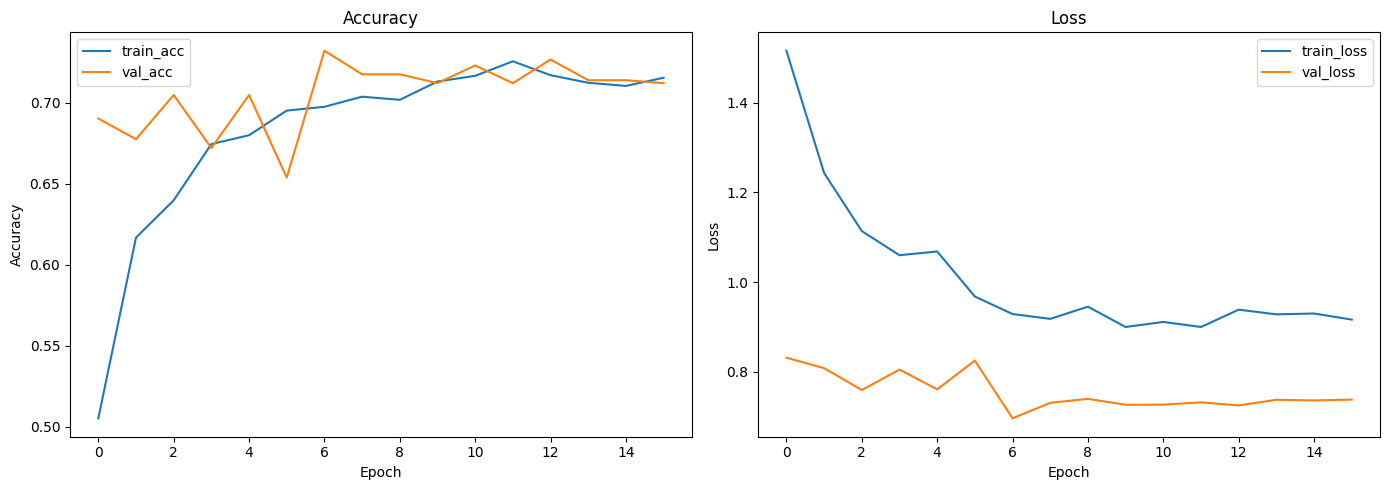

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/history_stage1.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/history_stage2.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/history_combined.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/figures/training_history.png


In [ ]:
# =========================
# CELL 16 — PLOT TRAINING HISTORY + SAVE HISTORY JSON
# =========================
def to_serializable_history(history_obj):
    return {k: [float(x) for x in v] for k, v in history_obj.history.items()}

def plot_history(histories, save_path=None):
    if not isinstance(histories, list):
        histories = [histories]

    all_acc = []
    all_val_acc = []
    all_loss = []
    all_val_loss = []

    for hist in histories:
        all_acc.extend(hist.history.get("accuracy", []))
        all_val_acc.extend(hist.history.get("val_accuracy", []))
        all_loss.extend(hist.history.get("loss", []))
        all_val_loss.extend(hist.history.get("val_loss", []))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(all_acc, label="train_acc")
    plt.plot(all_val_acc, label="val_acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(all_loss, label="train_loss")
    plt.plot(all_val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

history_stage1_path = os.path.join(LOGS_DIR, "history_stage1.json")
history_stage2_path = os.path.join(LOGS_DIR, "history_stage2.json")
history_combined_path = os.path.join(LOGS_DIR, "history_combined.json")

history_stage1_dict = to_serializable_history(history_stage1)
history_stage2_dict = to_serializable_history(history_stage2)

with open(history_stage1_path, "w") as f:
    json.dump(history_stage1_dict, f, indent=4)

with open(history_stage2_path, "w") as f:
    json.dump(history_stage2_dict, f, indent=4)

history_combined = {
    "stage1": history_stage1_dict,
    "stage2": history_stage2_dict
}

with open(history_combined_path, "w") as f:
    json.dump(history_combined, f, indent=4)

history_plot_path = os.path.join(FIGURES_DIR, "training_history.png")
plot_history([history_stage1, history_stage2], save_path=history_plot_path)

print("Saved:", history_stage1_path)
print("Saved:", history_stage2_path)
print("Saved:", history_combined_path)
print("Saved:", history_plot_path)

18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step
Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.9393    0.9705    0.9546       271
           1     0.4308    0.5000    0.4628        56
           2     0.6737    0.4267    0.5224       150
           3     0.2340    0.3793    0.2895        29
           4     0.3968    0.5682    0.4673        44

    accuracy                         0.7109       550
   macro avg     0.5349    0.5689    0.5393       550
weighted avg     0.7345    0.7109    0.7126       550



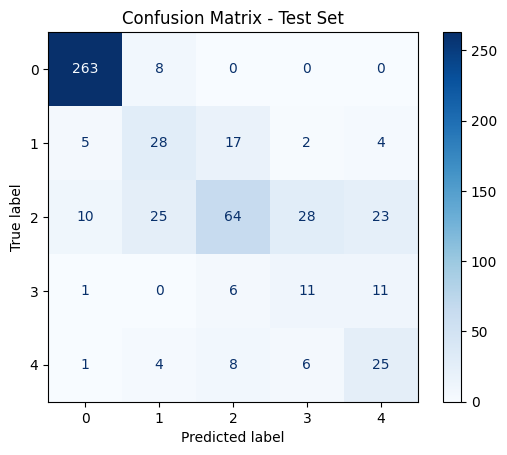

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/classification_report_test.txt
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/classification_report_test.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/confusion_matrix_values_test.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/figures/confusion_matrix_test.png


In [ ]:
# =========================
# CELL 17 — EVALUASI TEST SET + SAVE REPORTS
# =========================
test_probs = model.predict(test_ds, verbose=1)
test_preds = np.argmax(test_probs, axis=1)

report_text = classification_report(y_test, test_preds, digits=4)
report_dict = classification_report(y_test, test_preds, digits=4, output_dict=True)

print("Classification Report (Test Set):\n")
print(report_text)

report_txt_path = os.path.join(LOGS_DIR, "classification_report_test.txt")
report_json_path = os.path.join(LOGS_DIR, "classification_report_test.json")

with open(report_txt_path, "w") as f:
    f.write(report_text)

with open(report_json_path, "w") as f:
    json.dump(report_dict, f, indent=4)

cm = confusion_matrix(y_test, test_preds)
cm_dict = {"confusion_matrix": cm.tolist()}
cm_json_path = os.path.join(LOGS_DIR, "confusion_matrix_values_test.json")

with open(cm_json_path, "w") as f:
    json.dump(cm_dict, f, indent=4)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(NUM_CLASSES))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Set")

cm_plot_path = os.path.join(FIGURES_DIR, "confusion_matrix_test.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", report_txt_path)
print("Saved:", report_json_path)
print("Saved:", cm_json_path)
print("Saved:", cm_plot_path)

In [ ]:
# =========================
# CELL 18 — SAVE FINAL MODEL
# =========================
FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "mobilenetv2_aptos_final.keras")
model.save(FINAL_MODEL_PATH)

print("Model saved to:", FINAL_MODEL_PATH)

Model saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/models/mobilenetv2_aptos_final.keras


In [ ]:
# =========================
# CELL 19 — SAVE RUN INFO + SUMMARY METRICS
# =========================
stage1_best_val_acc = max(history_stage1.history.get("val_accuracy", [None]))
stage1_best_val_loss = min(history_stage1.history.get("val_loss", [None]))

stage2_best_val_acc = max(history_stage2.history.get("val_accuracy", [None]))
stage2_best_val_loss = min(history_stage2.history.get("val_loss", [None]))

final_train_acc = history_stage2.history.get("accuracy", [None])[-1]
final_val_acc = history_stage2.history.get("val_accuracy", [None])[-1]
final_train_loss = history_stage2.history.get("loss", [None])[-1]
final_val_loss = history_stage2.history.get("val_loss", [None])[-1]

summary_metrics = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "split_type": "global_train_val_test_split",
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "train_size": int(len(X_train)),
    "val_size": int(len(X_val)),
    "test_size": int(len(X_test)),
    "stage1_best_val_accuracy": None if stage1_best_val_acc is None else float(stage1_best_val_acc),
    "stage1_best_val_loss": None if stage1_best_val_loss is None else float(stage1_best_val_loss),
    "stage2_best_val_accuracy": None if stage2_best_val_acc is None else float(stage2_best_val_acc),
    "stage2_best_val_loss": None if stage2_best_val_loss is None else float(stage2_best_val_loss),
    "final_train_accuracy": None if final_train_acc is None else float(final_train_acc),
    "final_val_accuracy": None if final_val_acc is None else float(final_val_acc),
    "final_train_loss": None if final_train_loss is None else float(final_train_loss),
    "final_val_loss": None if final_val_loss is None else float(final_val_loss)
}

summary_metrics_path = os.path.join(LOGS_DIR, "run_summary_metrics.json")
with open(summary_metrics_path, "w") as f:
    json.dump(summary_metrics, f, indent=4)

print("Saved:", summary_metrics_path)
print(json.dumps(summary_metrics, indent=4))

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/run_summary_metrics.json
{
    "experiment_name": "exp1_baseline",
    "model_name": "mobilenet",
    "split_type": "global_train_val_test_split",
    "train_ratio": 0.7,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "train_size": 2563,
    "val_size": 549,
    "test_size": 550,
    "stage1_best_val_accuracy": 0.7322404384613037,
    "stage1_best_val_loss": 0.6965950727462769,
    "stage2_best_val_accuracy": 0.7267759442329407,
    "stage2_best_val_loss": 0.7253487706184387,
    "final_train_accuracy": 0.7155677080154419,
    "final_val_accuracy": 0.7122039794921875,
    "final_train_loss": 0.9165810346603394,
    "final_val_loss": 0.7384303212165833
}


In [ ]:
# =========================
# CELL 20 — QUICK RESULT SUMMARY
# =========================
print("\n" + "="*60)
print("BASELINE TRAINING FINISHED")
print("="*60)
print(f"Best Stage 1 Val Accuracy : {stage1_best_val_acc:.4f}" if stage1_best_val_acc is not None else "Best Stage 1 Val Accuracy : None")
print(f"Best Stage 2 Val Accuracy : {stage2_best_val_acc:.4f}" if stage2_best_val_acc is not None else "Best Stage 2 Val Accuracy : None")
print(f"Final Train Accuracy      : {final_train_acc:.4f}" if final_train_acc is not None else "Final Train Accuracy      : None")
print(f"Final Val Accuracy        : {final_val_acc:.4f}" if final_val_acc is not None else "Final Val Accuracy        : None")
print(f"Train size                : {len(X_train)}")
print(f"Val size                  : {len(X_val)}")
print(f"Test size                 : {len(X_test)}")
print("="*60)


BASELINE TRAINING FINISHED
Best Stage 1 Val Accuracy : 0.7322
Best Stage 2 Val Accuracy : 0.7268
Final Train Accuracy      : 0.7156
Final Val Accuracy        : 0.7122
Train size                : 2563
Val size                  : 549
Test size                 : 550


In [ ]:
# =========================
# CELL 21 — EXTRA IMPORTS FOR RESULT ANALYSIS
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [ ]:
# =========================
# CELL 22 — BUILD FINAL PREDICTION OBJECTS
# =========================
test_probs = model.predict(test_ds, verbose=1)
test_preds = np.argmax(test_probs, axis=1)

y_true = np.array(y_test)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)
print("Unique labels in y_true:", np.unique(y_true))

18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step
y_true shape: (550,)
y_pred shape: (550,)
y_prob shape: (550, 5)
Unique labels in y_true: [0 1 2 3 4]


In [ ]:
# =========================
# CELL 23 — MAIN BASELINE SUMMARY TABLE
# =========================
acc = accuracy_score(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
auc_macro_ovr = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

baseline_summary_df = pd.DataFrame([
    {
        "experiment_name": EXPERIMENT_NAME,
        "model_name": MODEL_NAME,
        "setup": "Centralized Baseline",
        "evaluation_set": "Test",
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "auc_macro_ovr": auc_macro_ovr,
        "auc_weighted_ovr": auc_weighted_ovr,
        "train_size": len(X_train),
        "val_size": len(X_val),
        "test_size": len(X_test)
    }
])

display(baseline_summary_df)

baseline_summary_csv = os.path.join(LOGS_DIR, "baseline_summary_table.csv")
baseline_summary_json = os.path.join(LOGS_DIR, "baseline_summary_table.json")

baseline_summary_df.to_csv(baseline_summary_csv, index=False)
baseline_summary_df.to_json(baseline_summary_json, orient="records", indent=4)

print("Saved:", baseline_summary_csv)
print("Saved:", baseline_summary_json)

,experiment_name,model_name,setup,evaluation_set,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro_ovr,auc_weighted_ovr,train_size,val_size,test_size
0,exp1_baseline,mobilenet,Centralized Baseline,Test,0.710909,0.534921,0.568928,0.53933,0.73449,0.710909,0.712626,0.903856,0.938022,2563,549,550


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/baseline_summary_table.csv
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/baseline_summary_table.json


In [ ]:
# =========================
# CELL 24 — LEARNING BEHAVIOUR TABLE
# =========================
learning_behaviour_df = pd.DataFrame({
    "epoch": list(range(1, len(history_stage1.history["accuracy"]) + len(history_stage2.history["accuracy"]) + 1)),
    "train_accuracy": history_stage1.history["accuracy"] + history_stage2.history["accuracy"],
    "val_accuracy": history_stage1.history["val_accuracy"] + history_stage2.history["val_accuracy"],
    "train_loss": history_stage1.history["loss"] + history_stage2.history["loss"],
    "val_loss": history_stage1.history["val_loss"] + history_stage2.history["val_loss"],
    "stage": (
        ["stage1"] * len(history_stage1.history["accuracy"]) +
        ["stage2"] * len(history_stage2.history["accuracy"])
    )
})

display(learning_behaviour_df.head())

learning_behaviour_csv = os.path.join(LOGS_DIR, "learning_behaviour_table.csv")
learning_behaviour_df.to_csv(learning_behaviour_csv, index=False)

print("Saved:", learning_behaviour_csv)

,epoch,train_accuracy,val_accuracy,train_loss,val_loss,stage
0,1,0.505267,0.690346,1.515643,0.831718,stage1
1,2,0.616855,0.677596,1.243197,0.808314,stage1
2,3,0.639875,0.704918,1.113781,0.759678,stage1
3,4,0.674600,0.672131,1.060030,0.805259,stage1
4,5,0.680062,0.704918,1.068378,0.761189,stage1


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/learning_behaviour_table.csv


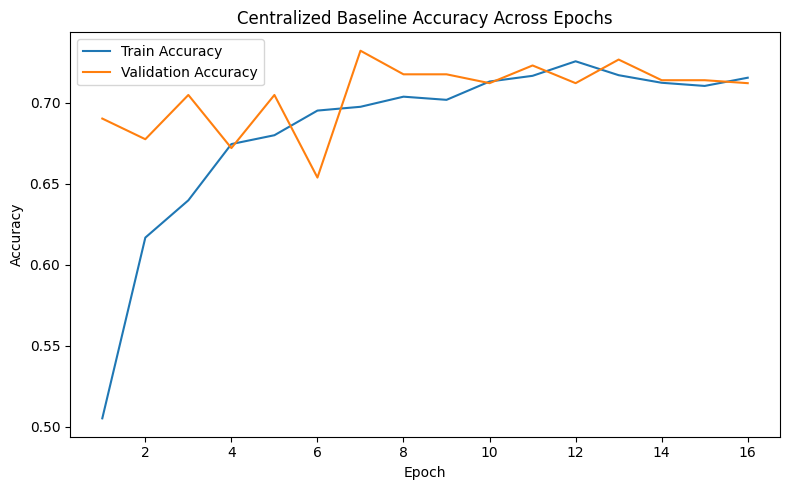

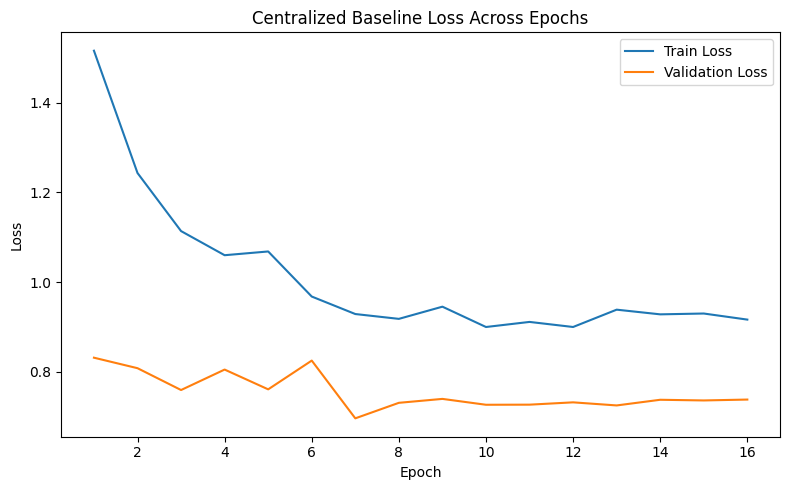

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/figures/baseline_accuracy_vs_epoch.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/figures/baseline_loss_vs_epoch.png


In [ ]:
# =========================
# CELL 25 — ACCURACY / LOSS LINE GRAPH
# =========================
epochs_all = list(range(1, len(learning_behaviour_df) + 1))

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_all, learning_behaviour_df["train_accuracy"], label="Train Accuracy")
plt.plot(epochs_all, learning_behaviour_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Centralized Baseline Accuracy Across Epochs")
plt.legend()
plt.tight_layout()

acc_plot_path = os.path.join(FIGURES_DIR, "baseline_accuracy_vs_epoch.png")
plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_all, learning_behaviour_df["train_loss"], label="Train Loss")
plt.plot(epochs_all, learning_behaviour_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Centralized Baseline Loss Across Epochs")
plt.legend()
plt.tight_layout()

loss_plot_path = os.path.join(FIGURES_DIR, "baseline_loss_vs_epoch.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", acc_plot_path)
print("Saved:", loss_plot_path)

In [ ]:
# =========================
# CELL 26 — PER-CLASS METRIC TABLE
# =========================
precision_cls, recall_cls, f1_cls, support_cls = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0
)

per_class_df = pd.DataFrame({
    "class": np.arange(NUM_CLASSES),
    "precision": precision_cls,
    "recall": recall_cls,
    "f1_score": f1_cls,
    "support": support_cls
})

display(per_class_df)

per_class_csv = os.path.join(LOGS_DIR, "per_class_metrics.csv")
per_class_json = os.path.join(LOGS_DIR, "per_class_metrics.json")

per_class_df.to_csv(per_class_csv, index=False)
per_class_df.to_json(per_class_json, orient="records", indent=4)

print("Saved:", per_class_csv)
print("Saved:", per_class_json)

,class,precision,recall,f1_score,support
0,0,0.939286,0.970480,0.954628,271
1,1,0.430769,0.500000,0.462810,56
2,2,0.673684,0.426667,0.522449,150
3,3,0.234043,0.379310,0.289474,29
4,4,0.396825,0.568182,0.467290,44


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/per_class_metrics.csv
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/per_class_metrics.json


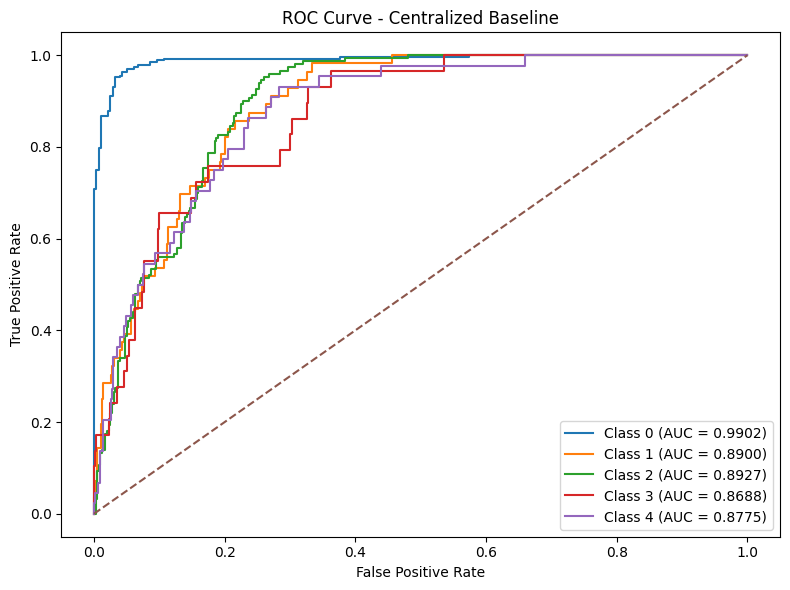

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/figures/roc_curve_baseline.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/roc_auc_per_class.json


In [ ]:
# =========================
# CELL 27 — ROC CURVE + AUC
# =========================
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

roc_auc_per_class = {}
plt.figure(figsize=(8, 6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_auc_per_class[f"class_{i}"] = float(roc_auc_val)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_val:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Centralized Baseline")
plt.legend()
plt.tight_layout()

roc_curve_path = os.path.join(FIGURES_DIR, "roc_curve_baseline.png")
plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

roc_auc_path = os.path.join(LOGS_DIR, "roc_auc_per_class.json")
with open(roc_auc_path, "w") as f:
    json.dump(roc_auc_per_class, f, indent=4)

print("Saved:", roc_curve_path)
print("Saved:", roc_auc_path)

<Figure size 700x600 with 0 Axes>

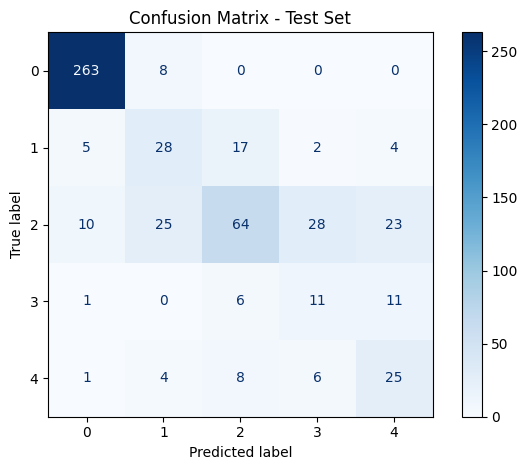

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/figures/confusion_matrix_heatmap_baseline.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/confusion_matrix_table.csv


In [ ]:
# =========================
# CELL 28 — CONFUSION MATRIX HEATMAP
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(NUM_CLASSES))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()

cm_heatmap_path = os.path.join(FIGURES_DIR, "confusion_matrix_heatmap_baseline.png")
plt.savefig(cm_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{i}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)]
)
cm_csv_path = os.path.join(LOGS_DIR, "confusion_matrix_table.csv")
cm_df.to_csv(cm_csv_path)

print("Saved:", cm_heatmap_path)
print("Saved:", cm_csv_path)

In [ ]:
# =========================
# CELL 29 — RESULT PACKAGE FOR FUTURE COMPARISON
# =========================
comparison_row = {
    "method": "Centralized",
    "model": MODEL_NAME,
    "accuracy": float(acc),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "auc_macro_ovr": float(auc_macro_ovr),
    "train_size": int(len(X_train)),
    "val_size": int(len(X_val)),
    "test_size": int(len(X_test)),
    "notes": "Global 70:15:15 split baseline, final metrics evaluated on test set"
}

comparison_row_path = os.path.join(LOGS_DIR, "comparison_ready_baseline.json")
with open(comparison_row_path, "w") as f:
    json.dump(comparison_row, f, indent=4)

print("Saved:", comparison_row_path)
print(json.dumps(comparison_row, indent=4))

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/APTOS/exp1_baseline/mobilenet/logs/comparison_ready_baseline.json
{
    "method": "Centralized",
    "model": "mobilenet",
    "accuracy": 0.7109090909090909,
    "precision_macro": 0.5349214211196294,
    "recall_macro": 0.5689277068946239,
    "f1_macro": 0.5393300499934413,
    "auc_macro_ovr": 0.9038561935097432,
    "train_size": 2563,
    "val_size": 549,
    "test_size": 550,
    "notes": "Global 70:15:15 split baseline, final metrics evaluated on test set"
}
